# India VIX + regime percentile visualization

End-to-end smoke + visualization that the Phase-8 #2/#3/#4 stack actually works:

1. `load_india_vix(...)` → reads from `data/cache/india_vix.parquet`; fetches from NSE if cache cold.
2. `regime_percentile(...)` → trailing-252-TD percentile rank of the VIX close series.
3. Plot:
   - **Blue line, left y-axis**: India VIX close
   - **Orange line, right y-axis**: trailing percentile rank (0–100)
   - **Grey shaded bands**: days where percentile > 75 (i.e., `regime_state == "OFF"`)

PORTFOLIO_MEMOIR.md §3.7 + §21.4 F9. Default threshold is 75th percentile per §3.1.

In [1]:
import sys
from pathlib import Path

# Make repo root importable so `src.*` resolves regardless of where the
# notebook was started from.
_REPO = Path.cwd()
while _REPO != _REPO.parent and not (_REPO / "src").is_dir():
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO))

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analytics.regime import regime_percentile
from src.data import india_vix_loader

## Load India VIX

In [2]:
# Pull ~4 years so the trailing-252-TD percentile rank has enough
# history to be non-NaN for at least ~3 of those years.
TODAY = date(2026, 5, 31)
START = date(2022, 1, 1)

vix = india_vix_loader.load_india_vix(START, TODAY, today_fn=lambda: TODAY)
print(f"rows: {len(vix)}")
print(f"range: {vix['date'].min().date()} → {vix['date'].max().date()}")
print(f"close: min={vix['india_vix_close'].min():.2f}, max={vix['india_vix_close'].max():.2f}, mean={vix['india_vix_close'].mean():.2f}")
vix.head()

rows: 1090
range: 2022-01-03 → 2026-05-29
close: min=9.15, max=31.98, mean=15.13


,date,india_vix_open,india_vix_high,india_vix_low,india_vix_close,india_vix_prev_close
0,2022-01-03,16.2225,16.8100,15.4525,16.4525,16.2225
1,2022-01-04,16.4525,16.6750,15.7100,16.1200,16.4525
2,2022-01-05,16.1200,17.3800,15.0875,17.2275,16.1200
3,2022-01-06,17.2275,18.4175,16.4000,17.9775,17.2275
4,2022-01-07,17.9775,18.0900,16.8600,17.6025,17.9775


## Compute trailing-252-TD percentile rank for every day

In [3]:
# Build a date-indexed close series, then apply regime_percentile per
# row. The function expects a pd.Series indexed by date; it handles the
# as_of lookup + 50%-of-lookback insufficient-history floor (returns NaN
# for early days where the trailing 252 TD window isn't half-full yet).
vix_close = vix.set_index("date")["india_vix_close"]

percentiles = pd.Series(
    [regime_percentile(vix_close, d.date(), lookback_td=252)
     for d in vix_close.index],
    index=vix_close.index, name="percentile",
)

valid = percentiles.dropna()
print(f"non-NaN percentile rows: {len(valid)} / {len(percentiles)}")
print(f"first valid date: {valid.index.min().date()}")
print(f"distribution of percentile rank values:")
print(valid.describe().round(2))

non-NaN percentile rows: 965 / 1090
first valid date: 2022-07-05
distribution of percentile rank values:
count    965.00
mean      40.98
std       33.50
min        0.00
25%        8.73
50%       34.52
75%       72.62
max       99.60
Name: percentile, dtype: float64


## Identify top-25-percentile (regime OFF) bands

`regime_state == "OFF"` when `percentile > 75`. We render those as grey vertical bands on the plot so it's obvious at a glance when the gate would have sat us out.

In [4]:
off_mask = (percentiles > 75).fillna(False)

def _runs(mask: pd.Series) -> list[tuple[pd.Timestamp, pd.Timestamp]]:
    """Return contiguous (start, end) inclusive ranges where mask is True."""
    runs: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    in_run = False
    run_start = None
    prev_idx = None
    for ts, on in mask.items():
        if on and not in_run:
            in_run = True
            run_start = ts
        elif not on and in_run:
            in_run = False
            runs.append((run_start, prev_idx))
        prev_idx = ts
    if in_run:
        runs.append((run_start, prev_idx))
    return runs

off_runs = _runs(off_mask)
print(f"OFF bands: {len(off_runs)}")
print(f"days in OFF: {int(off_mask.sum())} / {len(off_mask)} ({100*off_mask.mean():.1f}%)")
print("first 5 OFF bands:")
for s, e in off_runs[:5]:
    n_days = (e - s).days + 1
    print(f"  {s.date()} → {e.date()}  ({n_days} days)")

OFF bands: 26
days in OFF: 218 / 1090 (20.0%)
first 5 OFF bands:
  2023-12-06 → 2023-12-06  (1 days)
  2023-12-18 → 2024-01-03  (17 days)
  2024-01-08 → 2024-01-08  (1 days)
  2024-01-15 → 2024-03-06  (52 days)
  2024-03-11 → 2024-03-11  (1 days)


## Plot — VIX close + percentile, grey shading for top-25% bands

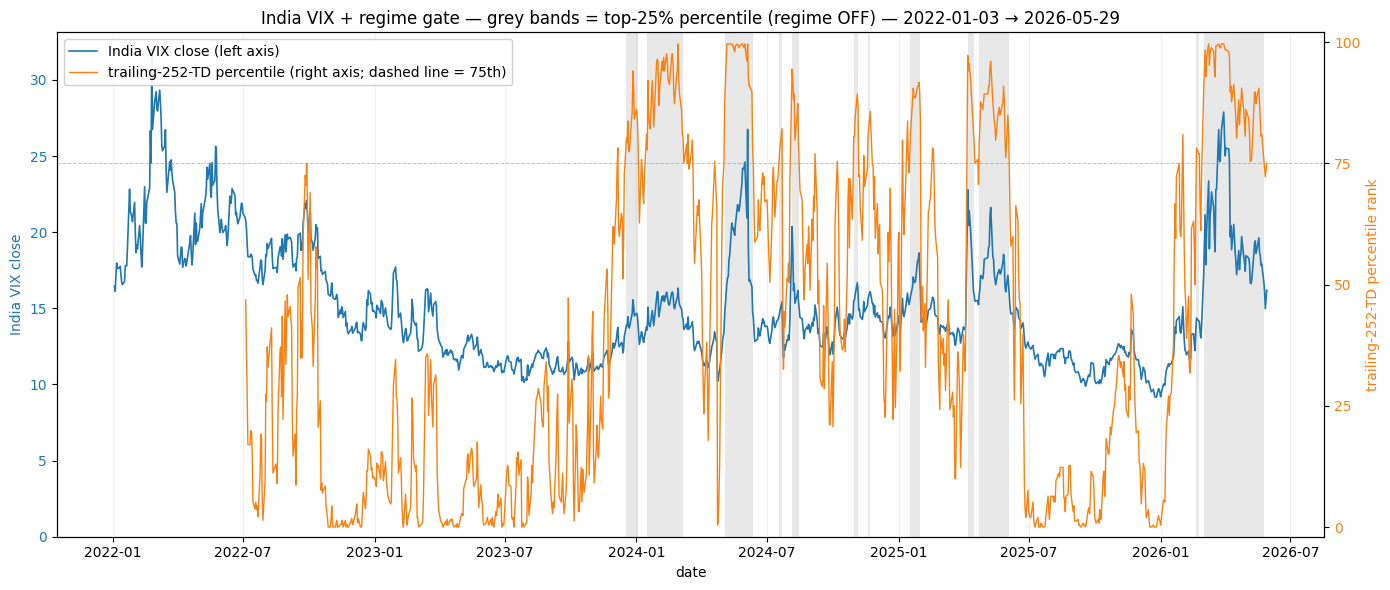

In [5]:
fig, ax_left = plt.subplots(figsize=(14, 6))

# Grey shading for OFF bands FIRST so it sits behind the lines.
for run_start, run_end in off_runs:
    ax_left.axvspan(run_start, run_end, color="grey", alpha=0.18, lw=0)

# Left axis: India VIX close.
vix_line, = ax_left.plot(
    vix_close.index, vix_close.values,
    color="#1f77b4", lw=1.2, label="India VIX close",
)
ax_left.set_xlabel("date")
ax_left.set_ylabel("India VIX close", color="#1f77b4")
ax_left.tick_params(axis="y", labelcolor="#1f77b4")
ax_left.set_ylim(bottom=0)
ax_left.grid(True, axis="x", alpha=0.2)

# Right axis: trailing-252-TD percentile rank.
ax_right = ax_left.twinx()
pct_line, = ax_right.plot(
    percentiles.index, percentiles.values,
    color="#ff7f0e", lw=1.0, label="trailing-252-TD percentile",
)
ax_right.axhline(75, color="#ff7f0e", lw=0.7, ls="--", alpha=0.6)
ax_right.set_ylabel("trailing-252-TD percentile rank", color="#ff7f0e")
ax_right.tick_params(axis="y", labelcolor="#ff7f0e")
ax_right.set_ylim(-2, 102)
ax_right.set_yticks([0, 25, 50, 75, 100])

# Single combined legend.
ax_left.legend(
    handles=[vix_line, pct_line],
    labels=["India VIX close (left axis)",
            "trailing-252-TD percentile (right axis; dashed line = 75th)"],
    loc="upper left", framealpha=0.92,
)

ax_left.set_title(
    f"India VIX + regime gate — grey bands = top-25% percentile (regime OFF) — "
    f"{vix_close.index.min().date()} → {vix_close.index.max().date()}"
)
fig.tight_layout()
plt.show()

## Quick gate stats

In [6]:
from src.analytics.regime import regime_state

states = pd.Series(
    [regime_state(vix_close, d.date(), threshold_pct=75.0, lookback_td=252)
     for d in vix_close.index],
    index=vix_close.index, name="state",
)
print("state counts:")
print(states.value_counts())
print()
valid_mask = ~percentiles.isna()
print("ON/OFF among valid (post-warmup) days only:")
print(states[valid_mask].value_counts(normalize=True).mul(100).round(1))

state counts:


state
ON     747
OFF    343
Name: count, dtype: int64

ON/OFF among valid (post-warmup) days only:
state
ON     77.4
OFF    22.6
Name: proportion, dtype: float64
